In [ ]:
# Libraries and Data Import

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Processed_Wide_Lag_Ready.csv')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# TUNING CONFIGS

# set seed
seed = 69
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


horizon = 13     # Number of Weeks to Forecast
model_layer_count = 1 # Number of Layers in model
max_lb = 52      # Maximum Lookback Window

lookbacks = [8, 13, 26, max_lb]      # Weeks
hiddens = [64, 128]           # Hidden Layer Size
lrs = [1e-2, 1e-3, 5e-4, 1e-4]             # Learning Rates
dropouts = [0]      # Dropout Rates


# Generate the combinations
keys = ['lookback', 'hidden', 'lr', 'dropout']
tuning_configs = [dict(zip(keys, v)) for v in itertools.product(lookbacks, hiddens, lrs, dropouts)]

# Add a constant epoch count to each
for config in tuning_configs:
    config['epochs'] = 200

print(f"Total Experiment Count: {len(tuning_configs)}")

Total Experiment Count: 32


In [ ]:
# DATA TRANSFORMATION

# cut out data from Sep. 3 2025 onwards
data = data[data['Week'] < '2025-09-03']

# Save Date Column and Drop From df
dates = data['Week'].values
df_numeric = data.drop(columns=['Week'])


# Convert to Numpy
full_data_matrix = df_numeric.values.astype(np.float32)

# Calculate Split Intervals
total_weeks = len(full_data_matrix)
train_end = int(total_weeks * 0.80)
val_end = int(total_weeks * 0.90)

train_raw = full_data_matrix[:train_end]
val_test_raw = full_data_matrix[train_end:]

# log transform volume to reduce outlier effect
full_data_matrix[:, -1] = np.log1p(full_data_matrix[:, -1])

# Apply standard scaler to the Volume
scaler = StandardScaler()
# Scale only Train Data
scaler.fit(full_data_matrix[:train_end])

full_data_matrix_scaled = full_data_matrix.copy()
full_data_matrix_scaled = scaler.transform(full_data_matrix)

print(f"Data shape: {full_data_matrix_scaled.shape}")

Data shape: (440, 353)


In [ ]:
# --- MODEL ARCHITECTURES ---

# RNN + LSTM MODEL
class FreightLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, 128)
        self.lstm = nn.LSTM(128, hidden_dim, num_layers=model_layer_count, batch_first=True, dropout=0)
        self.linear2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        x_enc = self.relu(self.linear1(x.view(-1, x.size(-1))))
        x_enc = x_enc.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(x_enc)
        return self.linear2(lstm_out[:, -1, :])


# NAIVE BASELINE MODEL
def run_naive_baselines(full_data, test_start_idx, horizon):
    props = full_data[:, :-1]
    actuals, persistence_preds, seasonal_preds = [], [], []

    for i in range(test_start_idx, len(props) - horizon):
        # Actual horizon window
        actual_window = props[i+1 : i+1+horizon].flatten()
        actuals.append(actual_window)

        # Standard Naive: Repeat current week for the whole horizon
        persistence_preds.append(np.tile(props[i], horizon))

        # Seasonal Naive: Take same window from last year
        if i >= 52:
            seasonal_preds.append(props[i-51 : i-51+horizon].flatten())

    p_mse = mean_squared_error(actuals, persistence_preds)
    s_mse = mean_squared_error(actuals[-(len(seasonal_preds)):], seasonal_preds) if seasonal_preds else None

    return {"persistence_mse": p_mse, "seasonal_mse": s_mse}

In [ ]:
# --- DATASET DEFINITION ---
class FreightDataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.lookback = lookback
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        # Input: The past 'lookback' weeks
        x = self.data[idx : idx + self.lookback]

        # Grabs "horizon" number of weeks
        y = self.data[idx + self.lookback : idx + self.lookback + self.horizon, :-1]
        # reshape y
        y_flat = y.reshape(-1)

        return x, y_flat


In [ ]:
# --- THE TRAINING & TUNING FUNCTION ---
def train_freight_model(train_end, val_end, config, horizon):
    # Split Non-Test Data Into Train, Val
    train_data = full_data_matrix_scaled[:train_end]
    val_data   = full_data_matrix_scaled[train_end - config['lookback'] : val_end]

    # Model Setup
    input_dim = train_data.shape[1]
    num_proportions = input_dim - 1
    output_dim = num_proportions * horizon

    train_ds = FreightDataset(train_data, config['lookback'], horizon)
    val_ds = FreightDataset(val_data, config['lookback'], horizon)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    model = FreightLSTM(input_dim, config['hidden'], output_dim, config['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.HuberLoss(delta=1.0)

    # --- EARLY STOPPING SETUP ---
    best_val_loss = float('inf')
    patience = 25  # Stop if no improvement after n epochs
    trigger_times = 0
    history = {'train_loss': [], 'val_loss': []}
    epochs_completed = 0

    for epoch in range(config['epochs']):
        epochs_completed += 1
        model.train()
        running_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                running_val_loss += criterion(model(batch_x), batch_y).item()

        avg_val = running_val_loss / len(val_loader)
        history['train_loss'].append(running_train_loss / len(train_loader))
        history['val_loss'].append(avg_val)

        # --- EARLY STOPPING LOGIC ---
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            trigger_times = 0
            # Save weights ONLY when we find a new global best
            torch.save(model.state_dict(), f"best_model_lb{config['lookback']}_h{config['hidden']}.pth")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return history, epochs_completed, model

In [ ]:
# --- RUN TRAINING LOOP ---

all_model_results = []

for i, config in enumerate(tuning_configs):
    print(f"\n--- Starting Trial {i+1}/{len(tuning_configs)} ---")
    print(f"Config: {config}")

    # Pass the horizon to the training function
    run_history, actual_epochs, _ = train_freight_model(train_end, val_end, config, horizon)
    best_score = min(run_history['val_loss'])

    # Structured exactly like your original request
    all_model_results.append({
        'Trial': i + 1,
        'Lookback': config['lookback'],
        'Hidden_Dim': config['hidden'],
        'LR': config['lr'],
        'Dropout': config['dropout'],
        'Epochs_Trained': actual_epochs,
        'Best_Val_Loss': best_score
    })

# Run Baselines (using the scaled matrix)
naive_results = run_naive_baselines(full_data_matrix_scaled, val_end, horizon)

# Baseline Entry
all_model_results.append({
    'Trial': 'BASELINE',
    'Lookback': 1,
    'Hidden_Dim': 0,
    'LR': 0,
    'Dropout': 0,
    'Epochs_Trained': 0,
    'Best_Val_Loss': naive_results['persistence_mse']
})

# Seasonal Entry
if naive_results['seasonal_mse'] is not None:
    all_model_results.append({
        'Trial': 'SEASONAL_BASE',
        'Lookback': 52,
        'Hidden_Dim': 0,
        'LR': 0,
        'Dropout': 0,
        'Epochs_Trained': 0,
        'Best_Val_Loss': naive_results['seasonal_mse']
    })

# --- FINAL TABULAR OUTPUT ---
results_df = pd.DataFrame(all_model_results)
results_df = results_df.sort_values(by='Best_Val_Loss', ascending=True)

print("\n" + "="*40)
print("FINAL MODEL COMPARISON (RANKED)")
print("="*40)
# We use to_string to ensure the entire table displays in the console/logs
print(results_df.to_string(index=False))

# Optional: Save results to CSV so you don't lose the record
results_df.to_csv('hyperparameter_tuning_results_huber2layer2.csv', index=False)


--- Starting Trial 1/32 ---
Config: {'lookback': 8, 'hidden': 64, 'lr': 0.01, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 109

--- Starting Trial 2/32 ---
Config: {'lookback': 8, 'hidden': 64, 'lr': 0.001, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 59

--- Starting Trial 3/32 ---
Config: {'lookback': 8, 'hidden': 64, 'lr': 0.0005, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 81

--- Starting Trial 4/32 ---
Config: {'lookback': 8, 'hidden': 64, 'lr': 0.0001, 'dropout': 0, 'epochs': 200}

--- Starting Trial 5/32 ---
Config: {'lookback': 8, 'hidden': 128, 'lr': 0.01, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 30

--- Starting Trial 6/32 ---
Config: {'lookback': 8, 'hidden': 128, 'lr': 0.001, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 50

--- Starting Trial 7/32 ---
Config: {'lookback': 8, 'hidden': 128, 'lr': 0.0005, 'dropout': 0, 'epochs': 200}
Early stopping at epoch 91

--- Starting Trial 8/32 ---
Config: {'lookback': 8, 'hidden': 128, 'l

In [ ]:
# --- FINAL MODEL TESTING + AGGREGATION FUNCTIONS ---

# --- AGGREGATE WEIGHTS ---
def get_aggregated_model(full_data_matrix_scaled, train_end, val_end, config, horizon, seeds=[10, 20, 30, 40, 50]):
    model_dicts = []
    train_data = full_data_matrix_scaled[:train_end]
    val_data = full_data_matrix_scaled[train_end - lb : val_end]

    input_dim = train_data.shape[1]
    num_proportions = input_dim - 1
    output_dim = num_proportions * horizon

    for s in seeds:
        random.seed(s)
        np.random.seed(s)
        torch.manual_seed(s)
        torch.cuda.manual_seed_all(s)

        print(f"Training Seed {s}...")
        # Ensure your train_freight_model returns (history, model_object)
        _, _, trained_model = train_freight_model(train_end, val_end, config, horizon)
        model_dicts.append(trained_model.state_dict())

    # Average the weights
    worker_state_dict = {key: torch.zeros_like(val) for key, val in model_dicts[0].items()}
    for key in worker_state_dict:
        for m_dict in model_dicts:
            worker_state_dict[key] += m_dict[key]
        worker_state_dict[key] /= len(model_dicts)

    final_model = FreightLSTM(input_dim, config['hidden'], output_dim, config['dropout'])
    final_model.load_state_dict(worker_state_dict)
    return final_model

# --- ERROR COLLECTION ---
def collect_detailed_errors(model, data, lookback, horizon, device):
    model.eval().to(device)
    ds = FreightDataset(data, lookback, horizon)
    loader = DataLoader(ds, batch_size=1, shuffle=False)

    errors = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            # Calculate MSE for this specific window
            mse = torch.mean((outputs - batch_y)**2).item()
            errors.append(mse)
    return errors

def get_naive_errors(full_data, start_idx, horizon):
    props = full_data[:, :-1]
    p_errors, s_errors = [], []

    for i in range(start_idx, len(props) - horizon):
        actual = props[i+1 : i+1+horizon].flatten()

        # Persistence (Daily/Standard Naive)
        p_pred = np.tile(props[i], horizon)
        p_errors.append(mean_squared_error(actual, p_pred))

        # Seasonal Naive
        if i >= 52:
            s_pred = props[i-51 : i-51+horizon].flatten()
            s_errors.append(mean_squared_error(actual, s_pred))

    return p_errors, s_errors


def plot_predictions_vs_actual(model, test_data, config, horizon, device, scaler):
    model.eval().to(device)
    ds = FreightDataset(test_data, config['lookback'], horizon)
    loader = DataLoader(ds, batch_size=1, shuffle=False)

    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x).cpu().numpy()
            all_preds.append(preds[0]) # Take the first horizon
            all_actuals.append(batch_y.numpy()[0])

    # Convert to arrays [Weeks, Features*Horizon]
    all_preds = np.array(all_preds)
    all_actuals = np.array(all_actuals)

    # We will look at the 1-week-ahead forecast (the first chunk of features)
    num_features = (test_data.shape[1] - 1)
    preds_1wk = all_preds[:, :num_features]
    actuals_1wk = all_actuals[:, :num_features]

    # --- PLOTTING ---
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot A: Mean Proportion Across All Commodities (The "System" View)
    axes[0].plot(np.mean(actuals_1wk, axis=1), label='Actual (System Mean)', color='black', linewidth=2)
    axes[0].plot(np.mean(preds_1wk, axis=1), label='Predicted (System Mean)', color='orange', linestyle='--')
    axes[0].set_title("System-Wide Commodity Fluctuations (Test Set)")
    axes[0].legend()

    # Plot B: A Specific High-Volatility Feature (The "Micro" View)
    # Let's pick feature index 10 as an example (e.g., a specific grain route)
    feature_idx = 10
    axes[1].plot(actuals_1wk[:, feature_idx], label=f'Actual (Feature {feature_idx})', color='blue')
    axes[1].plot(preds_1wk[:, feature_idx], label=f'Predicted (Feature {feature_idx})', color='red', linestyle='--')
    axes[1].set_title(f"Individual Commodity Route Tracking")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    plt.savefig("final_model_comparison_of_pred_vs_actual.png")


In [ ]:
# --- ROBUSTNESS EXPANSION OF 10 BEST MODELS  + FINAL MODEL SELECTION ---

# 1. Identify the Finalists
top_10_configs = results_df.nsmallest(10, 'Best_Val_Loss')

# Store results for the final box plot
final_comparison_data = {}

# 2. Add Naive Baselines first
p_errors, s_errors = get_naive_errors(full_data_matrix_scaled, val_end, horizon)
final_comparison_data['Naive_Persistence'] = p_errors
final_comparison_data['Naive_Seasonal'] = s_errors

# 3. The Big Loop: Run 5-seed aggregation for each finalist
for idx, row in top_10_configs.iterrows():
    lb = int(row['Lookback'])
    test_data = full_data_matrix_scaled[val_end - lb :]

    config = {
        'lookback': int(row['Lookback']),
        'hidden': int(row['Hidden_Dim']),
        'lr': row['LR'],
        'dropout': row['Dropout'],
        'epochs': 250 # Increased runway for the finals
      }

    trial_id = int(row['Trial'])
    label = f"Trial{trial_id}_LB{config['lookback']}_H{config['hidden']}"

    print(f"\n--- Running Robustness Test for: {label} ---")

    # Train 5 times and average the weights
    robust_model = get_aggregated_model(full_data_matrix_scaled, train_end, val_end, config, horizon, seeds=[10, 20, 30, 40, 50])

    # Save the aggregated weights for the symposium
    torch.save(robust_model.state_dict(), f"robust_model_{label}.pth")

    # Collect errors on the Test Set
    errors = collect_detailed_errors(robust_model, test_data, config['lookback'], horizon, device)
    final_comparison_data[label] = errors

# 4. Final Visualization and Data Export
# Sync lengths for the DataFrame (using the shortest list of errors)
min_len = min(len(v) for v in final_comparison_data.values())
df_final = pd.DataFrame({k: v[-min_len:] for k, v in final_comparison_data.items()})

# Save the raw error distributions
df_final.to_csv("top_10_robustness_results.csv", index=False)

# Calculate Mean and Variance for each model's test errors
stats_list = []
for model_name, errors in final_comparison_data.items():
    stats_list.append({
        'Model': model_name,
        'Mean MSE': np.mean(errors),
        'MSE Variance': np.var(errors),
        'Std Dev': np.std(errors)
    })

# Create and display the table
df_stats = pd.DataFrame(stats_list).sort_values(by='Mean MSE')
print("--- Top 10 Model Performance Summary ---")
print(df_stats.to_string(index=False))

# Save to CSV for report
df_stats.to_csv("top_10_model_stats.csv", index=False)


--- Running Robustness Test for: Trial30_LB52_H128 ---
Training Seed 10...
Early stopping at epoch 79
Training Seed 20...
Early stopping at epoch 83
Training Seed 30...
Early stopping at epoch 86
Training Seed 40...
Early stopping at epoch 92
Training Seed 50...
Early stopping at epoch 84

--- Running Robustness Test for: Trial1_LB8_H64 ---
Training Seed 10...
Early stopping at epoch 96
Training Seed 20...
Early stopping at epoch 77
Training Seed 30...
Early stopping at epoch 44
Training Seed 40...
Early stopping at epoch 98
Training Seed 50...
Early stopping at epoch 62

--- Running Robustness Test for: Trial22_LB26_H128 ---
Training Seed 10...
Early stopping at epoch 97
Training Seed 20...
Early stopping at epoch 100
Training Seed 30...
Early stopping at epoch 90
Training Seed 40...
Early stopping at epoch 84
Training Seed 50...
Early stopping at epoch 87

--- Running Robustness Test for: Trial14_LB13_H128 ---
Training Seed 10...
Early stopping at epoch 89
Training Seed 20...
Early 

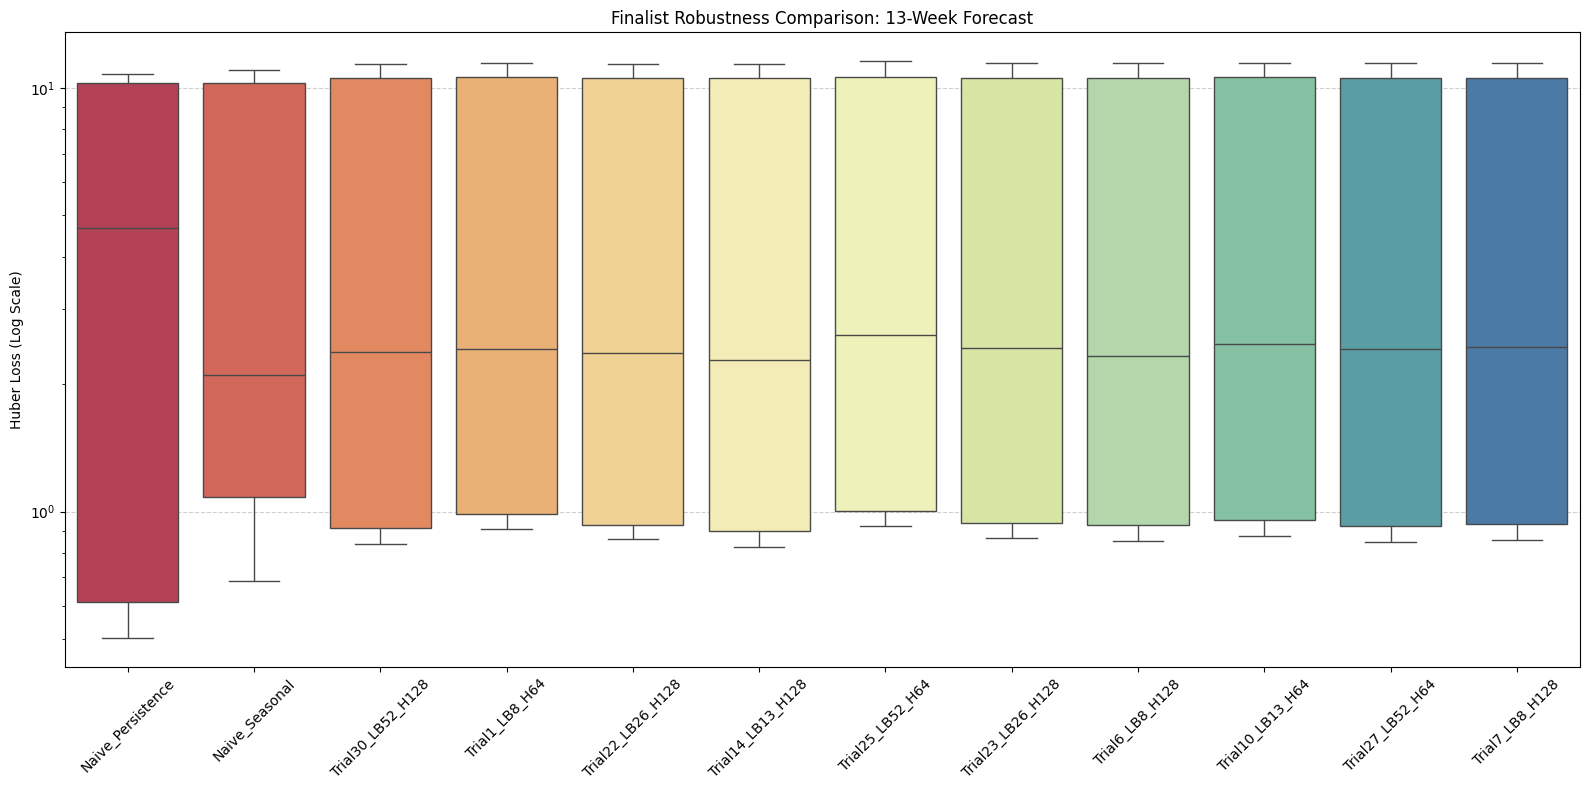

In [ ]:
# Create the Final Comparison Box Plot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_final, palette="Spectral", showfliers=False)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title(f"Finalist Robustness Comparison: {horizon}-Week Forecast")
plt.ylabel("Huber Loss (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("final_model_runoff_comparison.png")
plt.show()

The Champion Model is: Trial14_LB13_H128


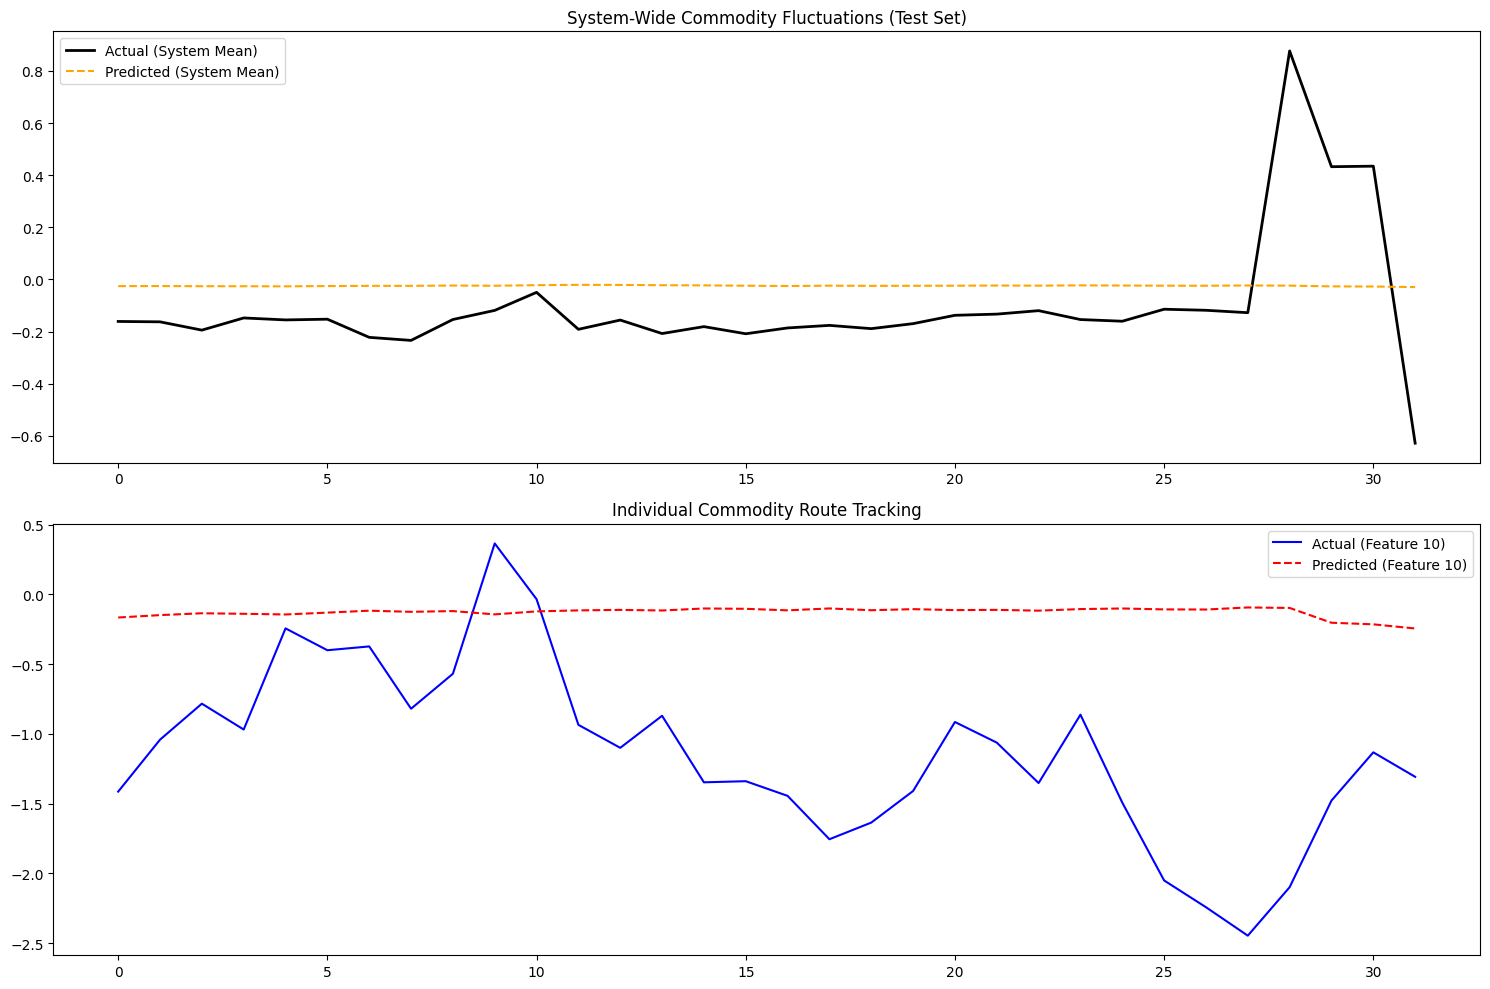

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Automatically find the winner from the Runoff results
# We look for the LSTM model (columns with 'LB' or 'Trial') with the lowest median MSE
model_cols = [c for c in df_final.columns if 'LB' in c or 'Trial' in c]
winner_name = df_final[model_cols].median().idxmin()
print(f"The Champion Model is: {winner_name}")

# 2. Re-create the model architecture and parameters
# Example winner_name: 'Trial42_LB26_H1024'
parts = winner_name.split('_')
win_lb = int([p for p in parts if 'LB' in p][0].replace('LB', ''))
win_h  = int([p for p in parts if 'H' in p][0].replace('H', ''))

# Extract the dropout from results_df for this specific winner
# Assuming 'Trial' was part of the name
trial_num = int([p for p in parts if 'Trial' in p][0].replace('Trial', ''))
win_dropout = results_df.loc[results_df['Trial'] == trial_num, 'Dropout'].values[0]

# 3. Prepare the Test Data Slice
# We need the last 10% of the data, but with a buffer of 'win_lb' to start predictions
test_data = full_data_matrix_scaled[val_end - win_lb:]

# 4. Initialize and load the weights
input_dim  = full_data_matrix_scaled.shape[1]
output_dim = (input_dim - 1) * horizon

champion_model = FreightLSTM(input_dim, win_h, output_dim, dropout=win_dropout).to(device)
champion_model.load_state_dict(torch.load(f"robust_model_{winner_name}.pth"))
champion_model.eval()


# 5. Plot the results!
# We pass win_lb in the config dict so the plotting function knows how to slide the window

plot_predictions_vs_actual(
    model=champion_model,
    test_data=test_data,
    config={'lookback': win_lb},
    horizon=horizon,
    scaler=scaler,
    device=device
)

Plotting results for: Trial30_LB52_H128


<Figure size 640x480 with 0 Axes>

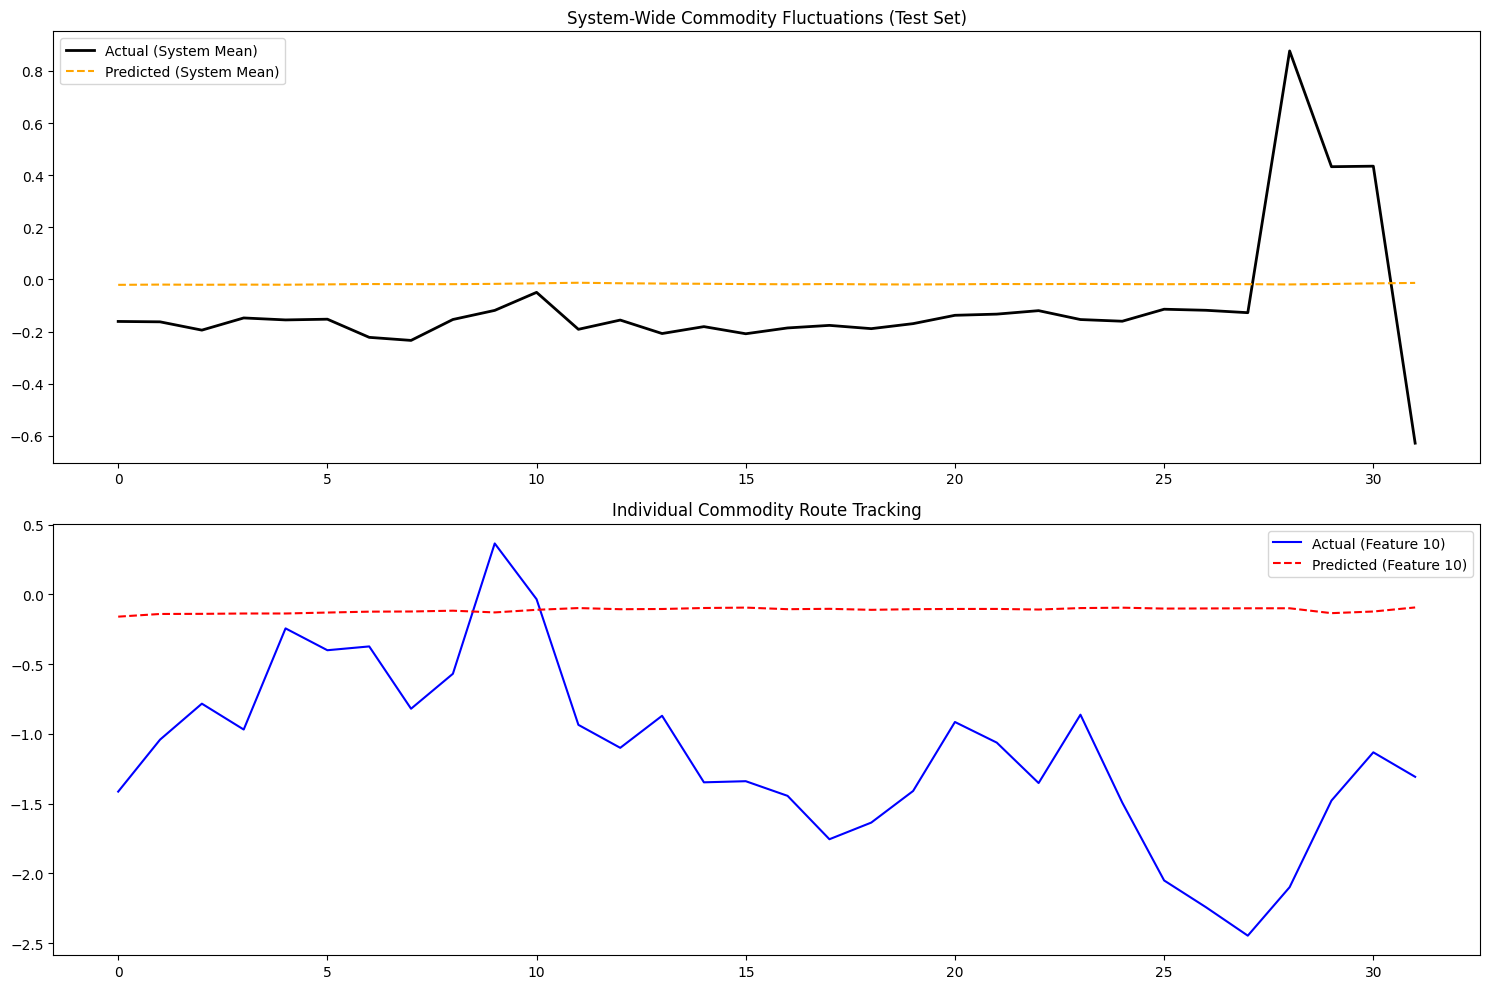

Plotting results for: Trial1_LB8_H64


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

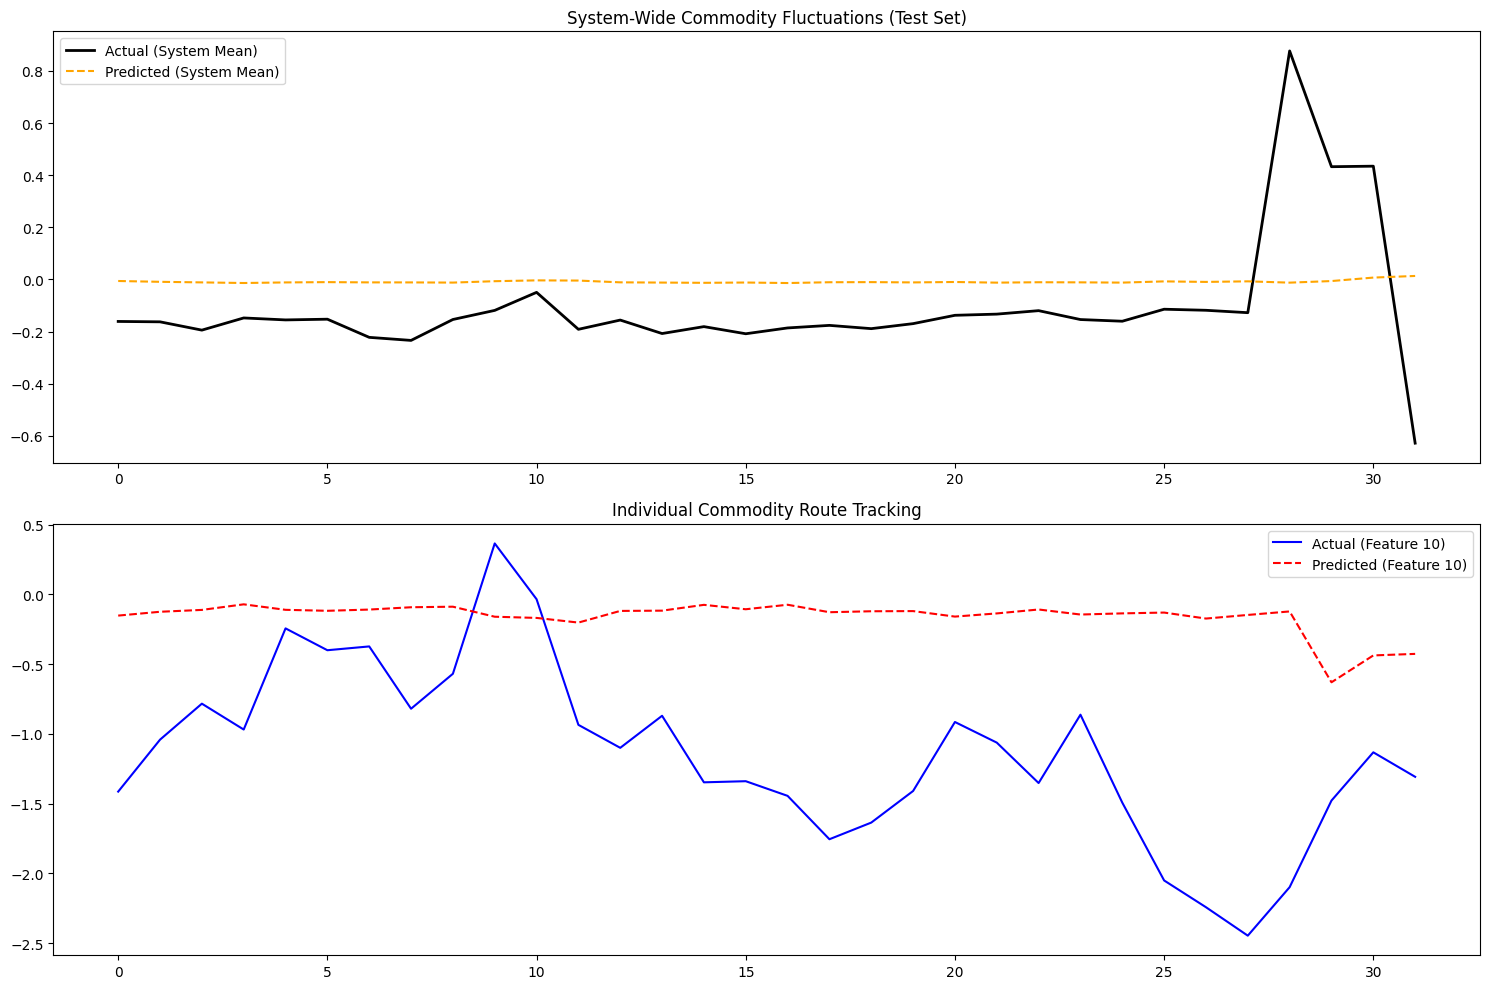

Plotting results for: Trial22_LB26_H128


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

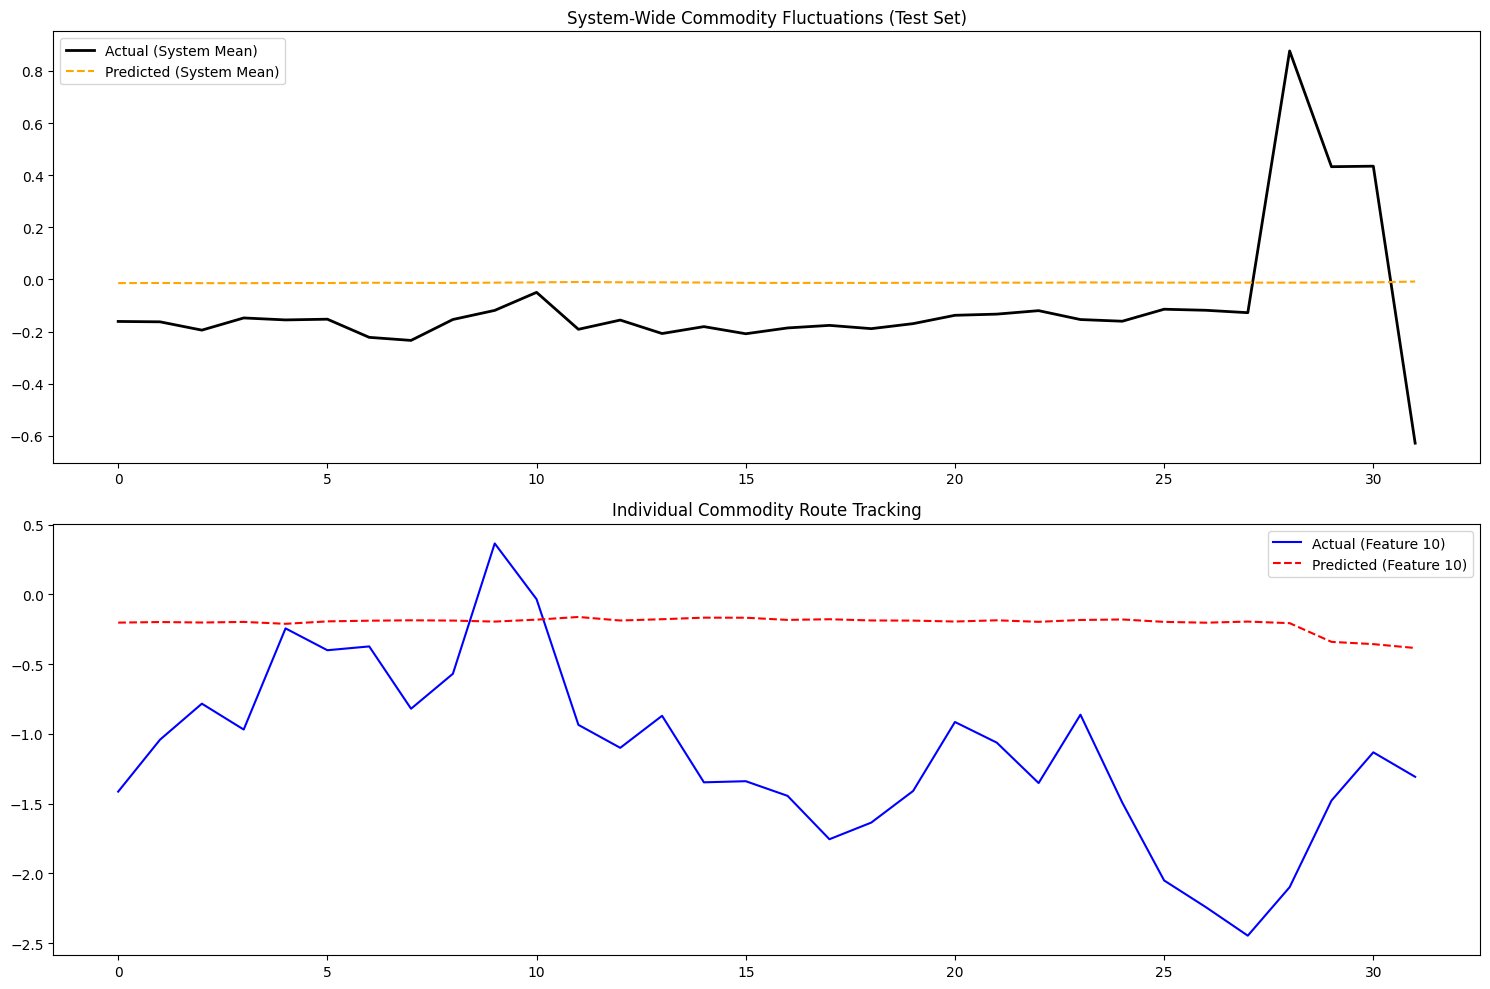

Plotting results for: Trial14_LB13_H128


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

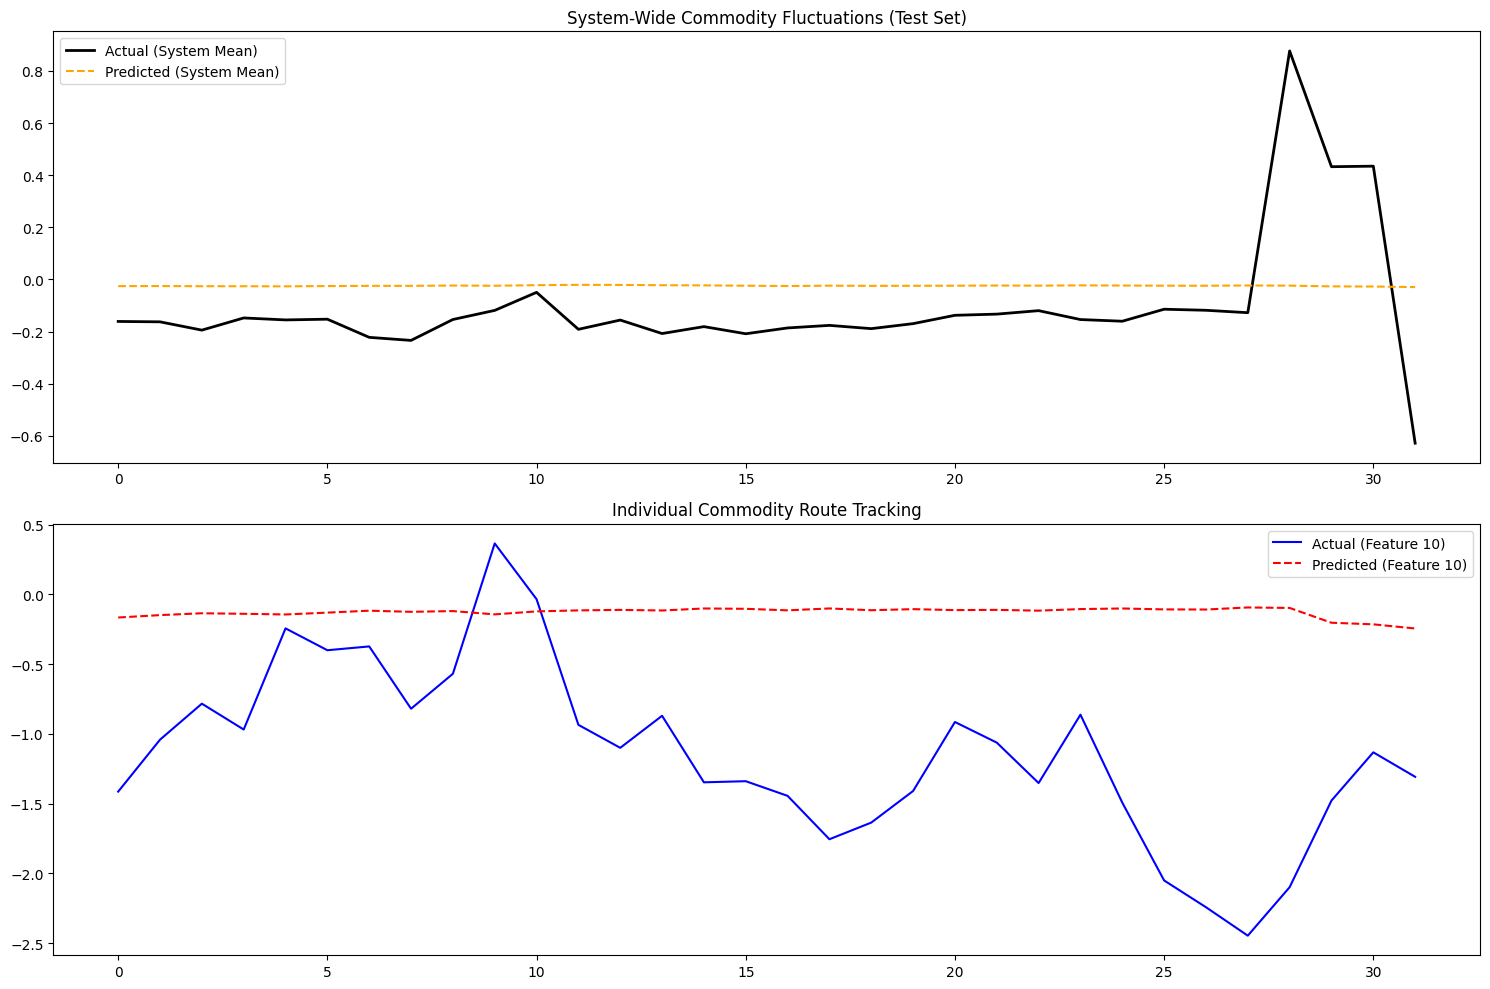

Plotting results for: Trial25_LB52_H64


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

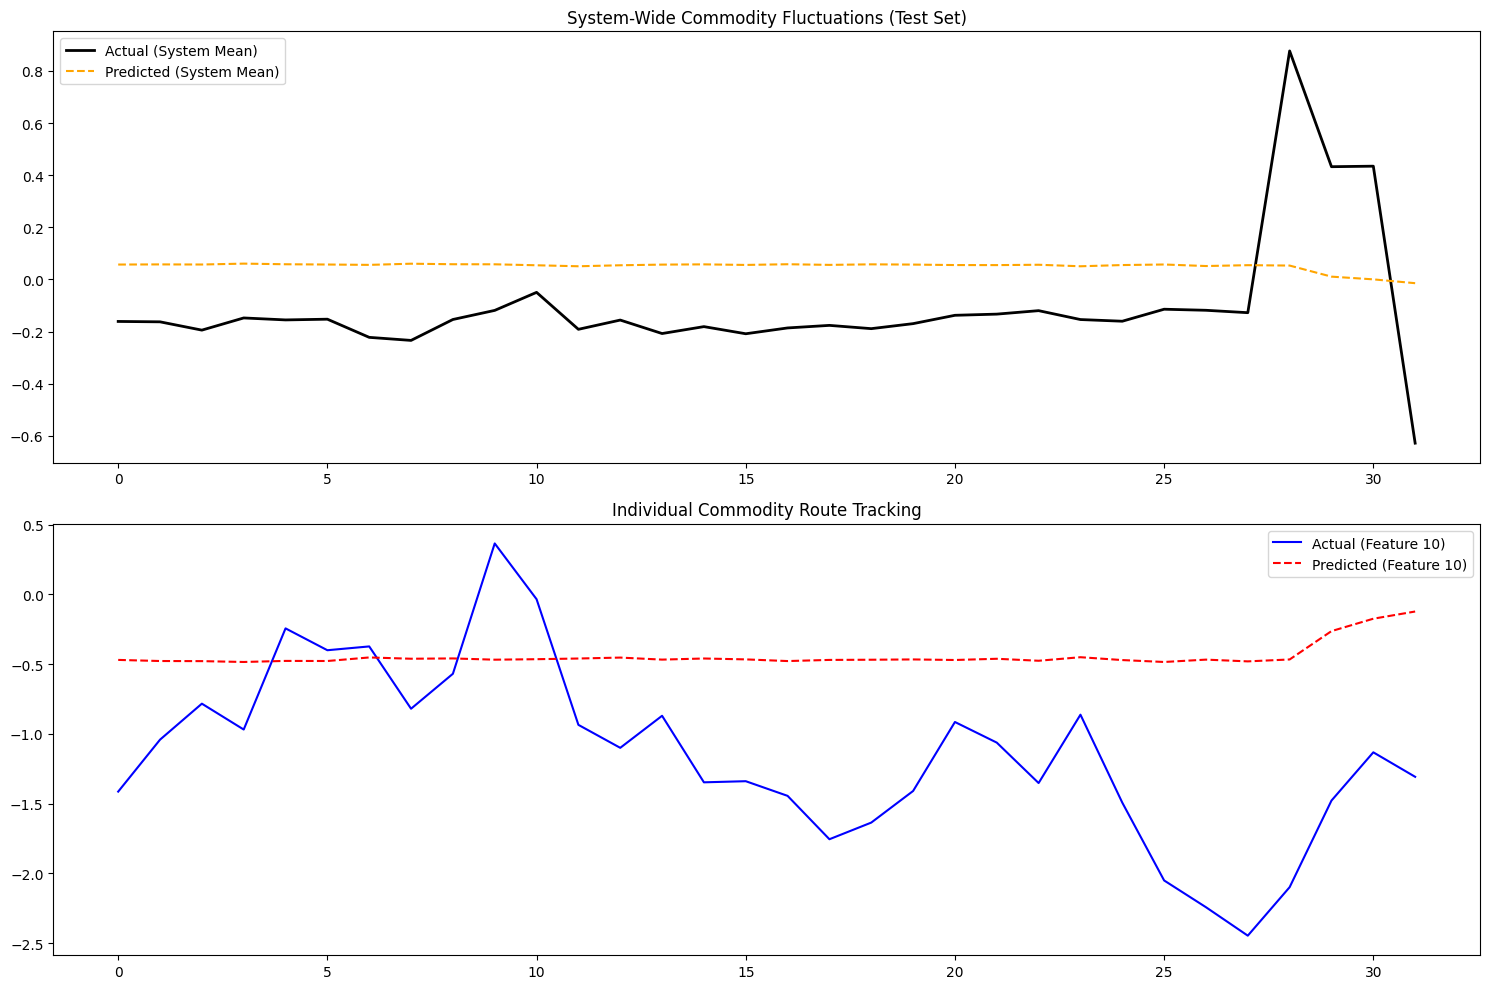

Plotting results for: Trial23_LB26_H128


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

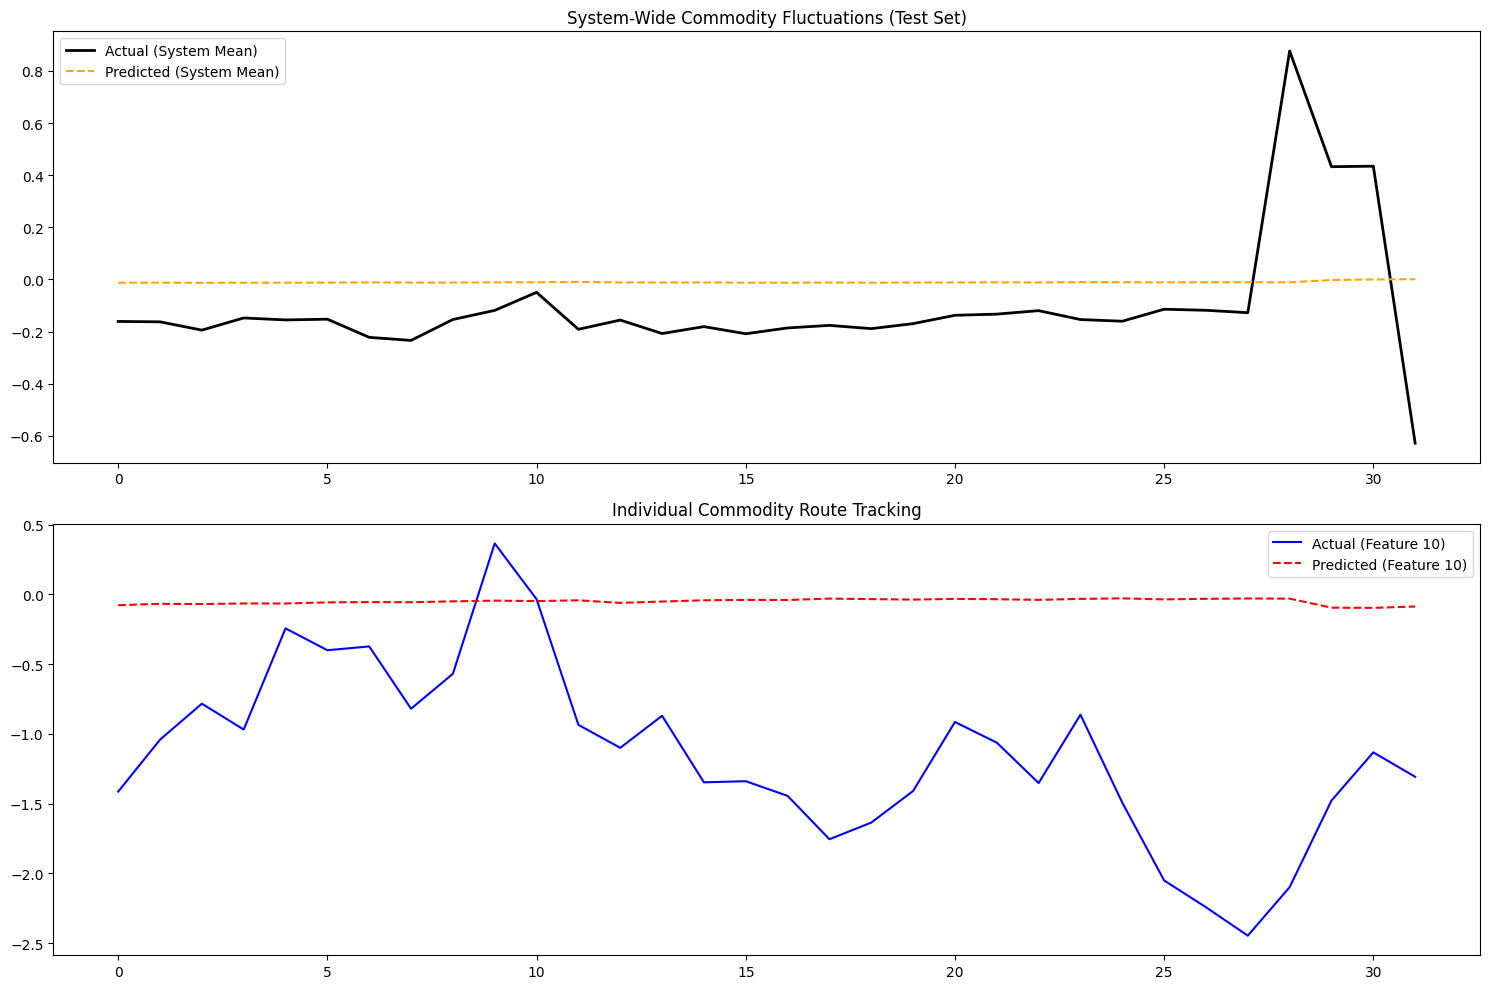

Plotting results for: Trial6_LB8_H128


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

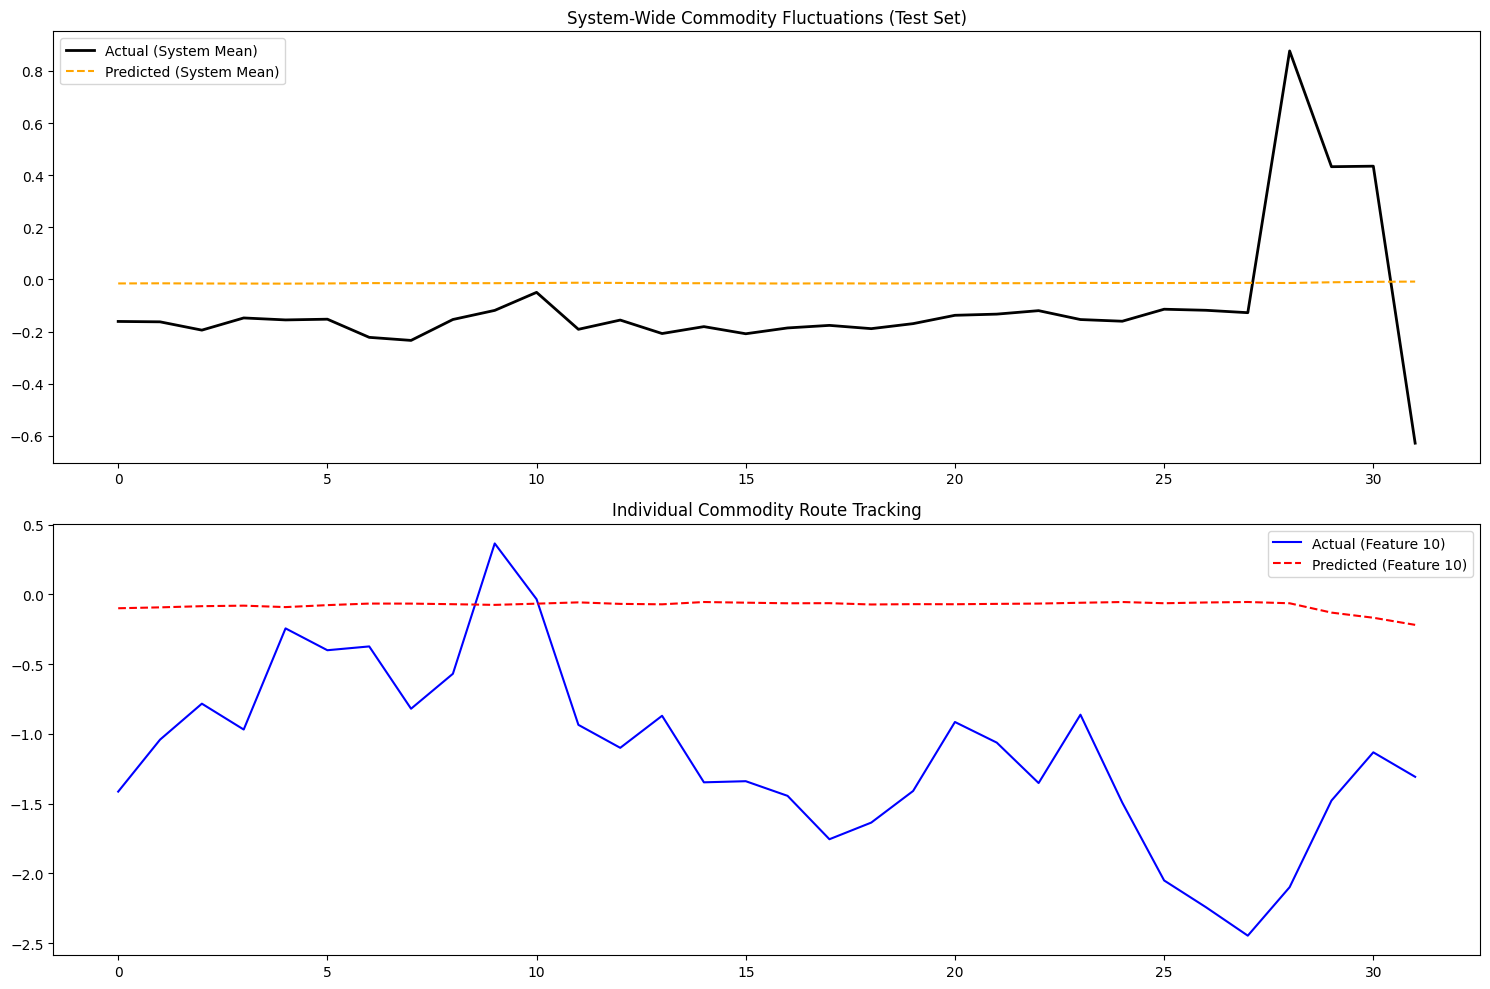

Plotting results for: Trial10_LB13_H64


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

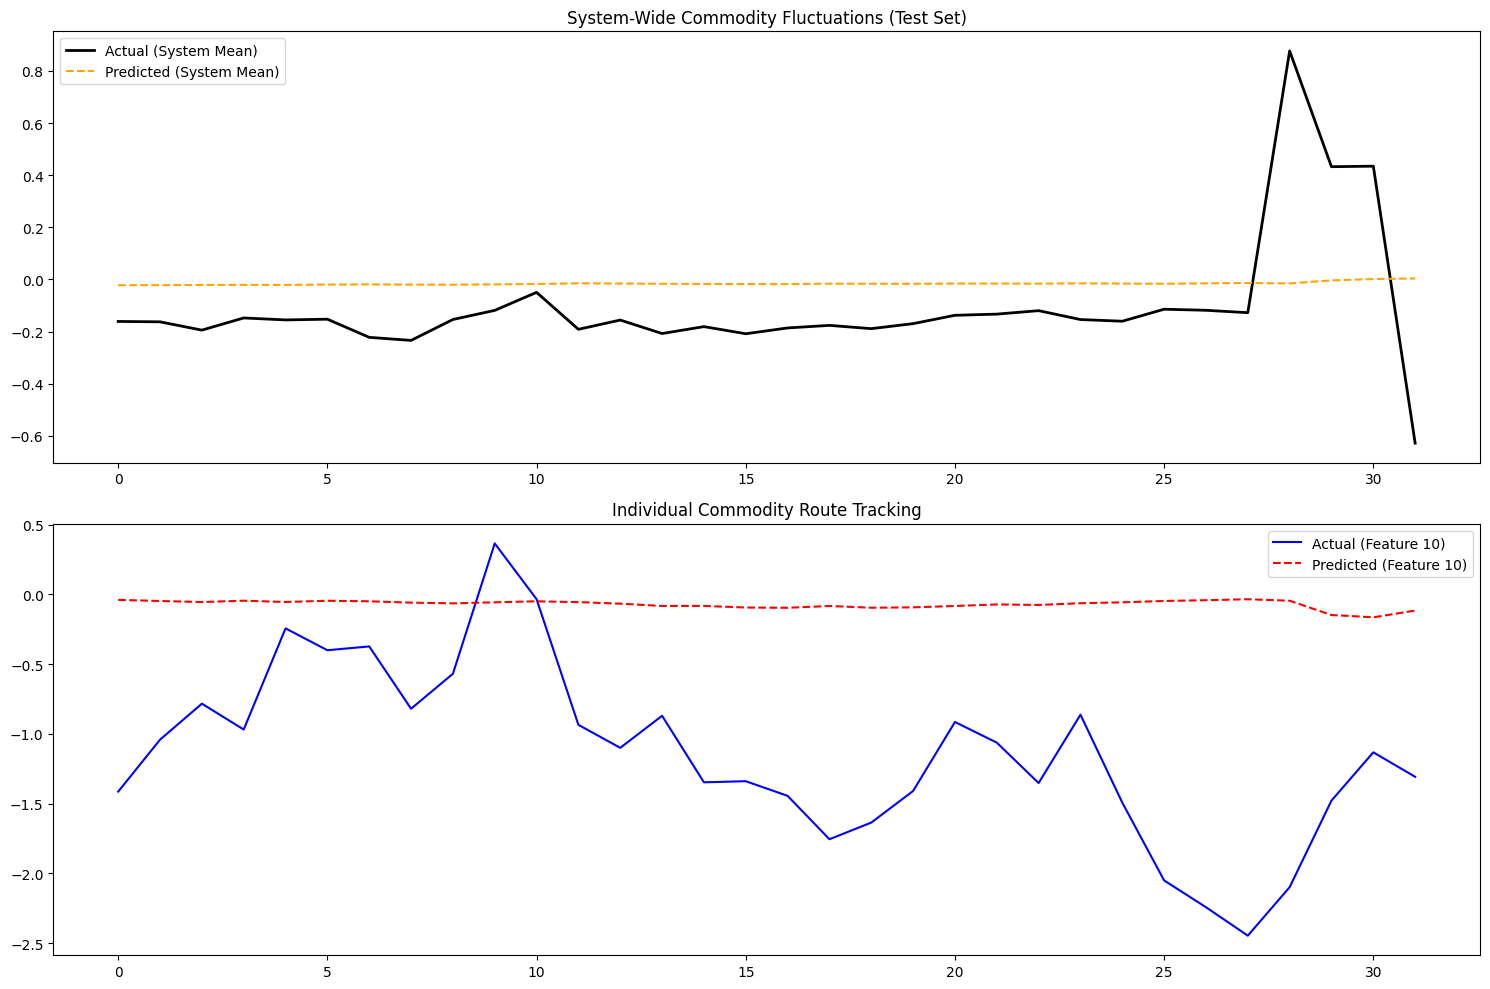

Plotting results for: Trial27_LB52_H64


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

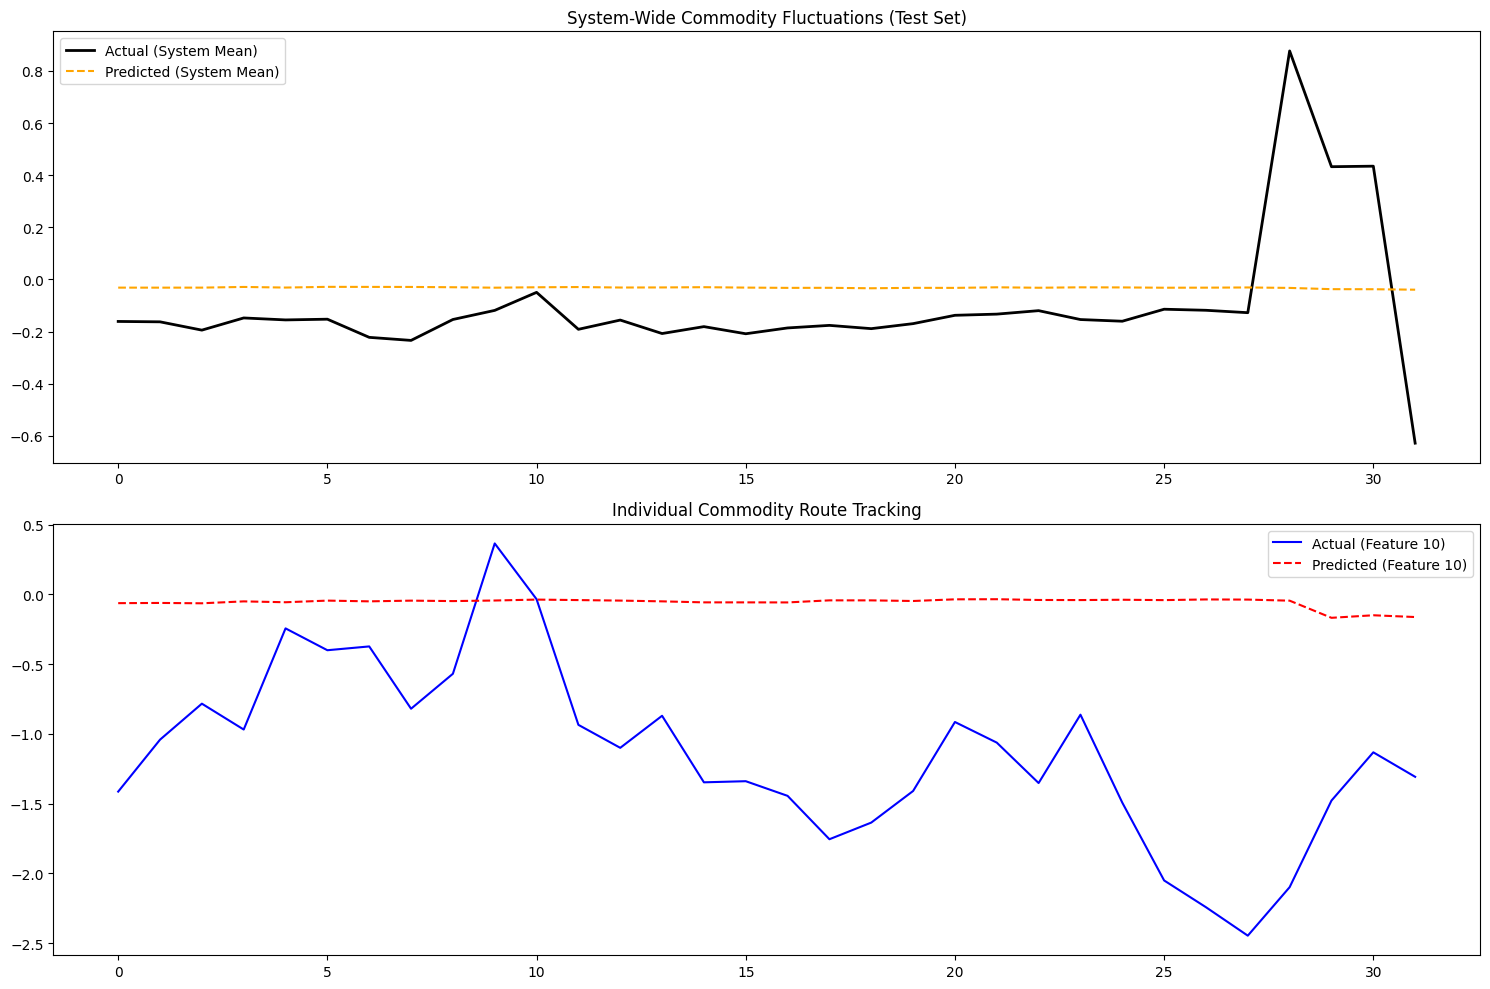

Plotting results for: Trial7_LB8_H128


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

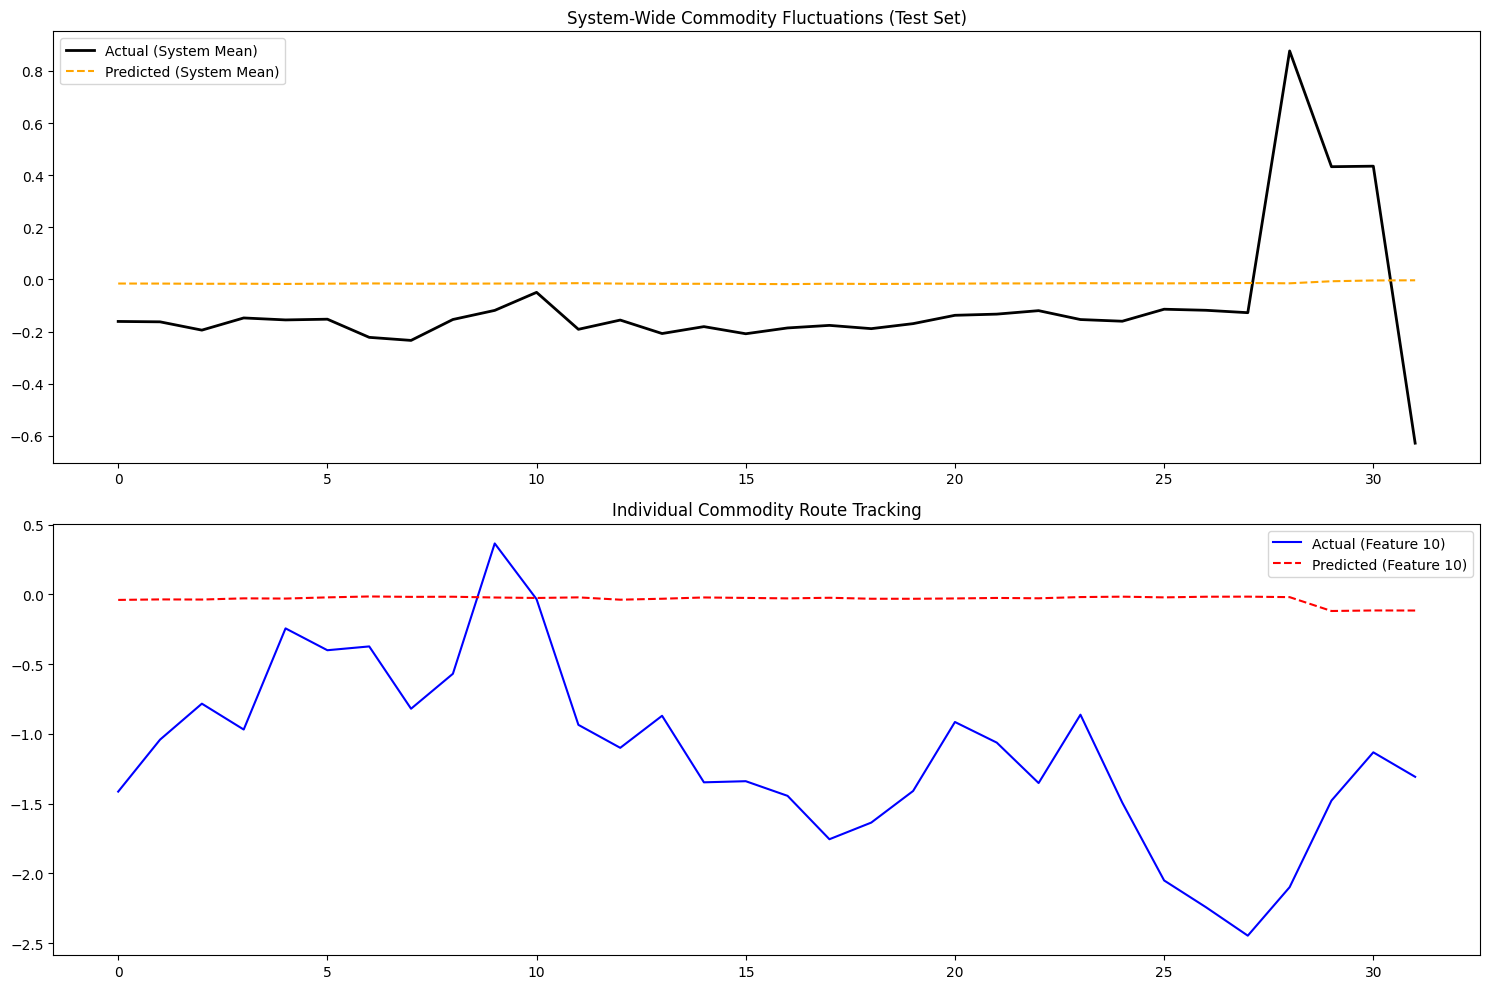

<Figure size 640x480 with 0 Axes>

In [ ]:
# Assuming top_10_configs is your dataframe of finalists
for idx, row in top_10_configs.iterrows():
    # Construct the winner name format used during saving
    # Adjust string formatting if your naming convention differs
    m_name = f"Trial{int(row['Trial'])}_LB{int(row['Lookback'])}_H{int(row['Hidden_Dim'])}"
    print(f"Plotting results for: {m_name}")

    # Re-initialize architecture
    m_lb = int(row['Lookback'])
    m_h = int(row['Hidden_Dim'])
    m_dropout = row['Dropout']
    m_layers = int(row.get('Layers', 1)) # Default to 1 if not in df

    temp_model = FreightLSTM(input_dim, m_h, output_dim, m_dropout).to(device)
    temp_model.load_state_dict(torch.load(f"robust_model_{m_name}.pth"))

    # Prepare the specific test slice for this lookback
    test_slice = full_data_matrix_scaled[val_end - m_lb:]

    # Plot (This will output 10 graphs in sequence)
    plt.figure()
    plot_predictions_vs_actual(
        model=temp_model,
        test_data=test_slice,
        config={'lookback': m_lb},
        horizon=horizon,
        scaler=scaler,
        device=device
    )